In [1]:
print("Welcome to the project")

Welcome to the project


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import tarfile
import urllib.request as ubr
def load_housing_data():
    tarball = Path("datasets/housing.tgz")
    if not tarball.is_file():
        Path("datasets").mkdir(parents=True, exist_ok  = True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        ubr.urlretrieve(url, tarball)
        with tarfile.open(tarball) as housing_tarball:
            housing_tarball.extractall(path = "datasets" , filter = "data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))        

housing_full = load_housing_data()            

In [11]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [15]:
housing_full['ocean_proximity'].value_counts()
housing_full['total_bedrooms'].count()


np.int64(20433)

<function matplotlib.pyplot.show(close=None, block=None)>

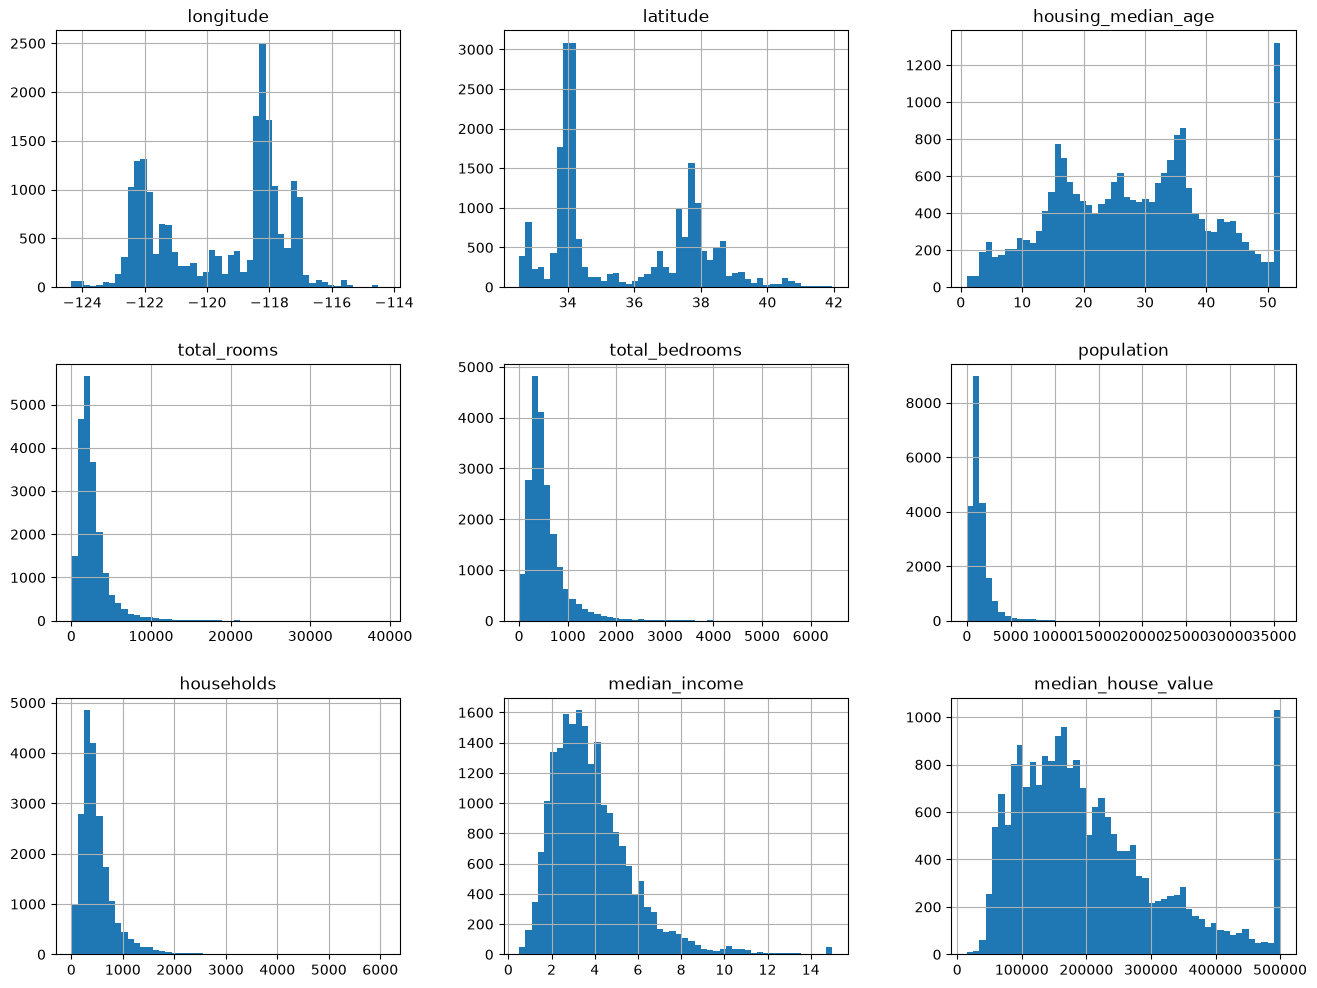

In [17]:
import matplotlib.pyplot as plt
housing_full.hist(bins = 50,figsize=(16,12))
plt.show

In [21]:
def create_test_data(data,percnt,rng):
    shuffled_indices = rng.permutation(len(data))
    test_size = int(len(data)*percnt);
    test_indice  = shuffled_indices[:test_size]
    train_indice = shuffled_indices[test_size:]
    return data.iloc[test_indice],data.iloc[train_indice]

rng = np.random.default_rng(seed = 45)
test_data,train_data = create_test_data(housing_full,0.2,rng)
print(len(test_data))
print(len(train_data))

4128
16512


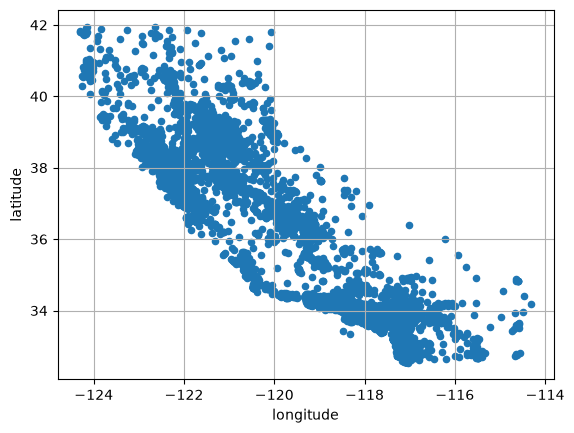

In [25]:
housing = train_data.copy()
housing.plot(kind = "scatter", x = "longitude" , y = "latitude" , grid=True)
plt.show()

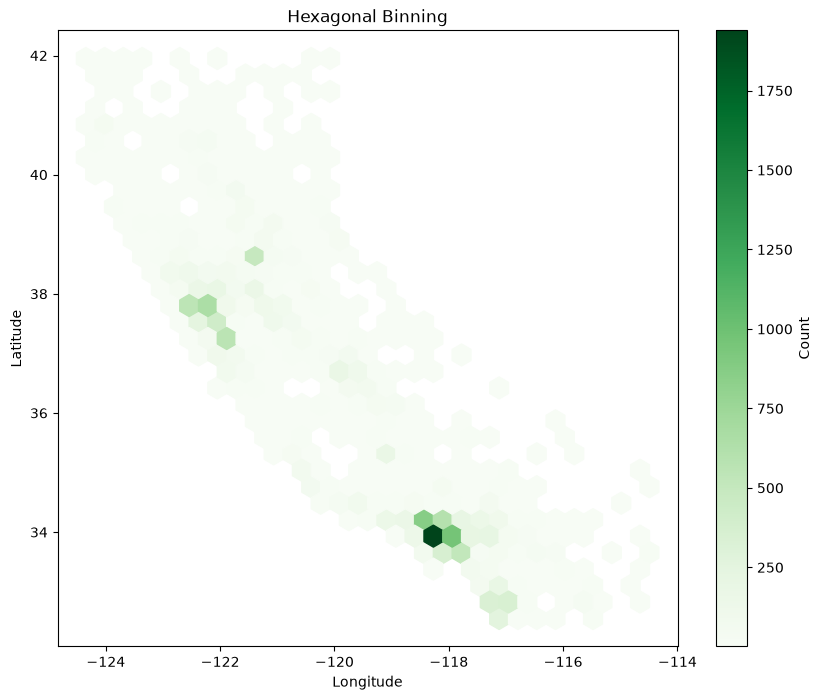

In [38]:
from sklearn.model_selection import train_test_split
housing_full["income_cat"] = pd.cut(housing_full["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],labels=[1, 2, 3, 4, 5])
strat_train_set, strat_test_set = train_test_split(
housing_full, test_size=0.2, stratify=housing_full["income_cat"],
random_state=42)
housing_1 = strat_train_set.copy()
plt.figure(figsize=(10, 8))
plt.hexbin(housing_1['longitude'], housing_1['latitude'], 
           gridsize=30, cmap='Greens', mincnt=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Count')
plt.title('Hexagonal Binning')
plt.show()

In [40]:
corr_matrix = housing.corr(numeric_only = True)
print(corr_matrix)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924717           -0.117265     0.046660   
latitude            -0.924717  1.000000            0.020878    -0.038523   
housing_median_age  -0.117265  0.020878            1.000000    -0.362069   
total_rooms          0.046660 -0.038523           -0.362069     1.000000   
total_bedrooms       0.071293 -0.068797           -0.321319     0.929599   
population           0.103906 -0.112971           -0.300297     0.856317   
households           0.058289 -0.073840           -0.305816     0.919381   
median_income       -0.018572 -0.077811           -0.118450     0.202753   
median_house_value  -0.054461 -0.136535            0.108142     0.139215   

                    total_bedrooms  population  households  median_income  \
longitude                 0.071293    0.103906    0.058289      -0.018572   
latitude                 -0.068797   -0.112971   -0.073840      -0.077811   
housing_

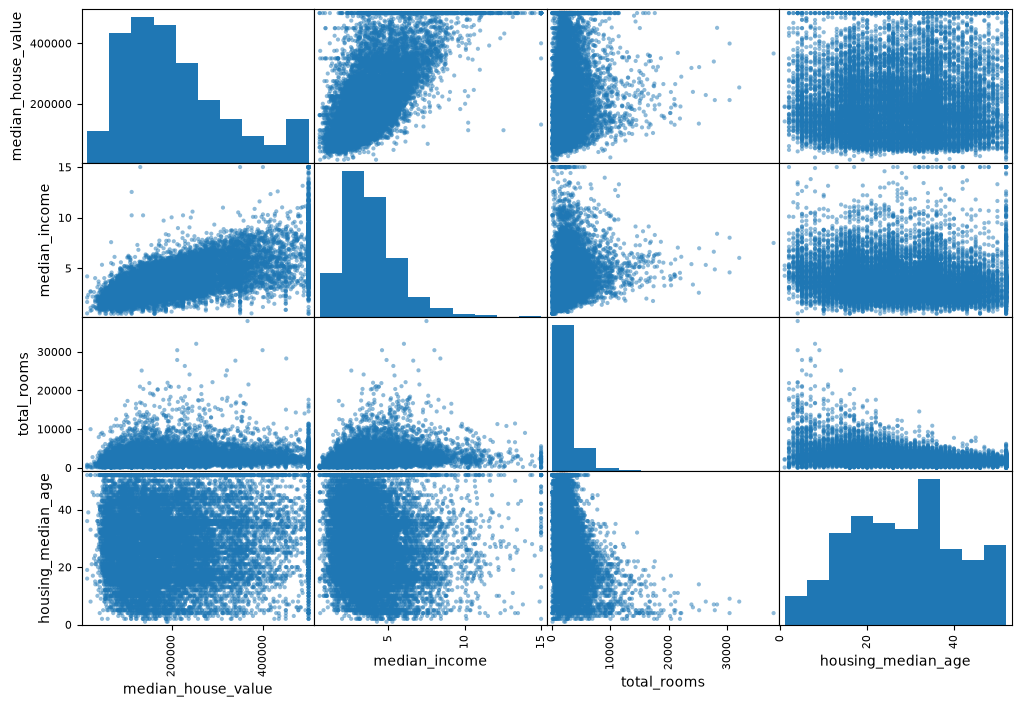

In [42]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize= (12,8))
plt.show()